In [15]:
# To run cells in this notebook, update the location of the MVTec dataset in the variables below

# Location of original MVTec data
data_location = '/home/suzy/datascientest/anomalie_proj/datasets/MVTec'

# Location of MVTec 'train' data for all object types (where 'train' and 'good' subdirectories have been removed)
obj_data = '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/objects/'

# Location of MVTec 'test' data for all objects but only 'good' subdirectory in each case
test_good_data = '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/objects_test_good/'

# Location of MVTec 'test' data for all objects (where all defect and good images have been combined into the same object type dir)
test_all_data = '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/objects_test_all/'


In [14]:
'''
The following bash scripts were used to create each above dataset from the original MVTec dataset 
(with scripts run in the same directory as that containing the MVTec dataset).


To create obj_data :

#!/bin/bash

new_base=/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/objects 

for obj in bottle  cable  capsule  carpet  grid  hazelnut  leather  metal_nut  pill  screw  tile  toothbrush  transistor  wood  zipper
do 
        mkdir ${new_base}/${obj} 
        cp  ${obj}/train/good/* ${new_base}/${obj}
done



To create test_good_data : 

#!/bin/bash

new_base=/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/objects_test_good 

for obj in bottle  cable  capsule  carpet  grid  hazelnut  leather  metal_nut  pill  screw  tile  toothbrush  transistor  wood  zipper
do 
        mkdir ${new_base}/${obj} 
        cp  ${obj}/test/good/* ${new_base}/${obj}
done



To create test_all_data:

#!/bin/bash

new_base=/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/objects_test_all 

for obj in bottle  cable  capsule  carpet  grid  hazelnut  leather  metal_nut  pill  screw  tile  toothbrush  transistor  wood  zipper
do 
        mkdir ${new_base}/${obj}
        classes=$(ls ${obj}/test)
        
        for class in ${classes}
        do
                files=$(ls ${obj}/test/${class})
                for file in ${files}
                do 
                        cp ${obj}/test/${class}/${file} ${new_base}/${obj}/${class}_${file}
        
                done
        done
done

'''

'\nThe following bash scripts were used to create each above dataset from the original MVTec dataset \n(with scripts run in the same directory as that containing the MVTec dataset).\n\n\nTo create obj_data :\n\n#!/bin/bash\n\nnew_base=/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/objects \n\nfor obj in bottle  cable  capsule  carpet  grid  hazelnut  leather  metal_nut  pill  screw  tile  toothbrush  transistor  wood  zipper\ndo \n        mkdir ${new_base}/${obj} \n        cp  ${obj}/train/good/* ${new_base}/${obj}\ndone\n\n\n\nTo create test_good_data : \n\n#!/bin/bash\n\nnew_base=/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/objects_test_good \n\nfor obj in bottle  cable  capsule  carpet  grid  hazelnut  leather  metal_nut  pill  screw  tile  toothbrush  transistor  wood  zipper\ndo \n        mkdir ${new_base}/${obj} \n        cp  ${obj}/test/good/* ${new_base}/${obj}\ndone\n\n\n\nTo create test_all_data:\n\n#!/bin/bash\n\nnew_base=/home/suzy/datascientest/anom

# Modelisation Step of Anomaly Detection Project: Deep Learning Part

### Initial model plan (with CNN Classifiers): 
1. Train a CNN for multi-class classification of object types (see if it achieves better performance than random forests for texture types)
2. Train a CNN for multi-class classification of anomaly type for single type of object
3. See if data augmentation techniques for minority anomaly classes improves performance
4. If unable to perform multi-class anomaly classification, recast to binary classification (anomaly or not)
5. Look into transfer learning options


In [3]:
# Library imports

from pathlib import Path
import os
import cv2
import numpy as np
import pandas as pd

# Imports for visualizations
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Imports for ML
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.metrics import classification_report_imbalanced


In [4]:
# Imports for CNNs

# Imports for building the model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
# Imports for model training
from tensorflow.keras.callbacks import EarlyStopping

# Imports for image transformations
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import Resizing
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomBrightness
from tensorflow.keras.layers import RandomContrast 
from tensorflow.keras.layers import RandomTranslation

# Importing the image_dataset_from_directory utility from Keras
from keras.utils import image_dataset_from_directory

# Importing loss function
from tensorflow.keras.losses import CategoricalCrossentropy


/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [5]:
# Functions

def plot_training(model_history):
    train_loss = model_history.history["loss"]
    val_loss = model_history.history["val_loss"]
    
    train_acc = model_history.history["accuracy"]
    val_acc = model_history.history["val_accuracy"]
    
    plt.figure(figsize=(20, 8))
    
    # Plot the MSE loss
    plt.subplot(121)
    plt.plot(train_loss)
    plt.plot(val_loss)
    plt.title('Model Loss per Epoch')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='best')
    
    # Plot the Mean Absolute Error (MAE)
    plt.subplot(122)
    plt.plot(train_acc)
    plt.plot(val_acc)
    plt.title('Accuracy per Epoch')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='best')
    
    plt.show()


def get_predictions_and_labels(model, dataset):
    true_labels = []
    pred_labels = []

    for images, labels in dataset:
        
        preds = model.predict(images, verbose=0)  # Get the model's predictions
        pred_labels.extend(np.argmax(preds, axis=-1))  # Get the predicted labels (argmax)

        true_labels.extend(labels.numpy())  # Get the true labels

    return np.array(true_labels), np.array(pred_labels)


def plot_cm(y_true, y_pred, title=None, labels=None):
    plt.figure(figsize=(10, 10))  # Create a large figure for the confusion matrix
    cnf_matrix = confusion_matrix(y_true, y_pred, normalize='true')  # Compute the normalized confusion matrix
    ax = sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")  # Plot the confusion matrix as a heatmap
    ax.set_ylabel('True Labels')
    ax.set_xlabel('Predicted Labels')
    if title is not None:
        ax.set_title(title)
    if labels is not None:
      ax.set_xticklabels(labels)
      ax.set_yticklabels(labels)
    ax.set_xticklabels(ax.get_xticklabels(), ha='center', rotation=45)  # Horizontal alignment
    ax.set_yticklabels(ax.get_yticklabels(), va='center', rotation=45)
    plt.show()


def cm_bin(y_true, y_pred):
    cnf_matrix = pd.crosstab(y_true, y_pred, rownames=['True Class'], colnames=['Predicted Class'])
    display(cnf_matrix)
   

In [6]:
# CNN model for 15 class object classification

# Define the model input
inputs = Input(shape=(None, None, 3))

# Image transformations: resizing, normalization
x = Resizing(256, 256)(inputs)    # Resize the images to 100x100 pixels
x = Rescaling(1./255)(x)        # Normalize the pixel values to be between 0 and 1

# Adding the convolutional layer
x = Conv2D(filters=32, 
           kernel_size=(3, 3), 
           activation="relu",
           padding="valid")(x)

# Adding the pooling layer to reduce the size of the data
x = MaxPooling2D(pool_size=(2, 2), padding='valid')(x)

# Adding a dropout layer to prevent overfitting
x = Dropout(0.3)(x)

# Flattening the data to pass it to the dense layer
x = Flatten()(x)

# Dense layer for making the prediction
outputs = Dense(
    units=15,
    activation='softmax')(x) 

# Define the model with the specified inputs and outputs
model = Model(inputs=inputs, outputs=outputs)

model.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])



In [15]:
# CNN model for binary anomaly classification

# Define the model input
inputs = Input(shape=(None, None, 3))

# Image transformations: resizing, normalization
x = Resizing(100, 100)(inputs)    # Resize the images to 100x100 pixels
x = Rescaling(1./255)(x)        # Normalize the pixel values to be between 0 and 1

# Adding the convolutional layer
x = Conv2D(filters=32, 
           kernel_size=(3, 3), 
           activation="relu",
           padding="valid")(x)

# Adding the pooling layer to reduce the size of the data
x = MaxPooling2D(pool_size=(2, 2), padding='valid')(x)

# Adding a dropout layer to prevent overfitting
x = Dropout(0.3)(x)

# Flattening the data to pass it to the dense layer
x = Flatten()(x)

# Dense layer for making the prediction
outputs = Dense(
    units=1,
    activation='sigmoid')(x) 

# Define the model with the specified inputs and outputs
model_bin = Model(inputs=inputs, outputs=outputs)

model_bin.compile(optimizer="adam", loss='binary_crossentropy', metrics=['accuracy'])



In [6]:
# Callbacks for model training

early_stopping = EarlyStopping(
                                patience=5, 
                                min_delta=0.01, 
                                mode='min',
                                monitor='val_loss')


## CNN for multi-class object classification

In [7]:
# Defining datasets (MVTec 'train' 'good' only)

data_dir = f"{obj_data}"

train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,       # Fraction of the data used for validation
    subset="training",          # Load the training data
    seed=42,                    # Seed for data splitting
    batch_size=32               # Batch size
)

val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,       # Fraction of the data used for validation
    subset="validation",        # Load the validation data
    seed=42,
    batch_size=32
)


Found 3629 files belonging to 15 classes.
Using 2904 files for training.
Found 3629 files belonging to 15 classes.
Using 725 files for validation.


In [8]:
# Number of batches in the training dataset
print("Number of batch in train_ds:", train_ds.cardinality().numpy())

# Number of batches in the validation dataset
print("Number of batch in val_ds:", val_ds.cardinality().numpy())


Number of batch in train_ds: 91
Number of batch in val_ds: 23


In [9]:
categories = [p.name for p in Path(f"{obj_data}").iterdir() if p.is_dir()]

print('Object type to label mapping:\n')
for label, obj in enumerate(categories):
    print(f'{label}: {obj}')
    

Object type to label mapping:

0: bottle
1: cable
2: capsule
3: carpet
4: grid
5: hazelnut
6: leather
7: metal_nut
8: pill
9: screw
10: tile
11: toothbrush
12: transistor
13: wood
14: zipper


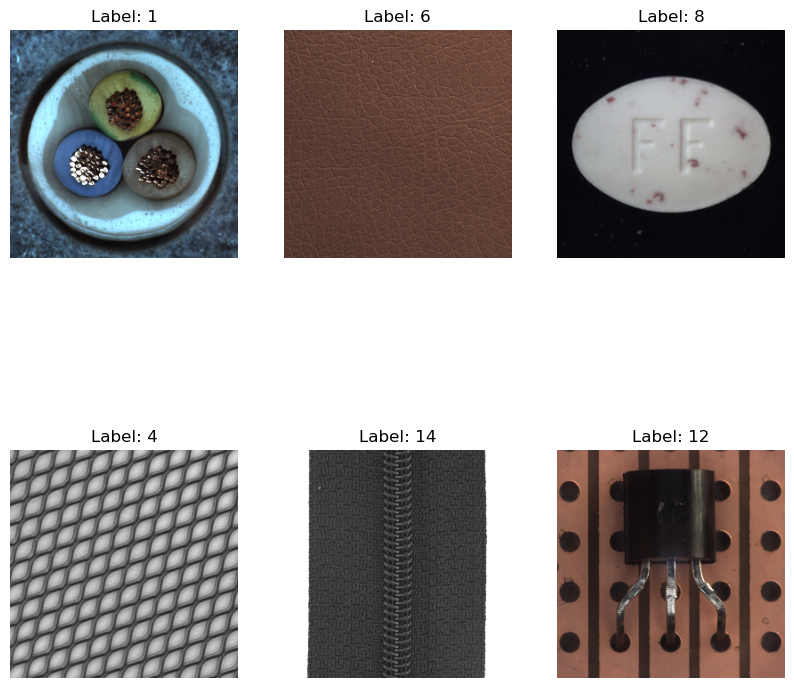

In [28]:
# Define the number of images to display
number_of_images = 6

# Create a figure for displaying
plt.figure(figsize=(10,10))

# Get a batch of images from train_ds
for images, labels in train_ds.take(1):
    # Display the images from the batch
    for i in range(number_of_images):
        ax = plt.subplot(2, 3, i + 1) 
        plt.imshow(images[i].numpy().astype("uint8"))  # Convert the image to integer for display
        plt.axis("off") 
        plt.title(f"Label: {labels[i].numpy()}")  # Display the label of the image (+18 since our age data starts at 18 and labels start at 0)

# Show the images
plt.show()


In [10]:
# Train 15 class model defined at top of notebook

model_history = model.fit(train_ds,
                          validation_data=val_ds,
                          epochs=30,
                          callbacks=[early_stopping]
                         ) 


Epoch 1/30


2026-02-04 17:39:34.877774: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 264257536 exceeds 10% of free system memory.
2026-02-04 17:39:35.909277: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 66064384 exceeds 10% of free system memory.
2026-02-04 17:39:36.129884: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 66064384 exceeds 10% of free system memory.
2026-02-04 17:39:36.130253: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 66064384 exceeds 10% of free system memory.
2026-02-04 17:39:36.629162: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 66064384 exceeds 10% of free system memory.


91/91 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.8595 - loss: 2.3681 - val_accuracy: 1.0000 - val_loss: 0.0199
Epoch 2/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.9997 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 3/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 4/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 1.0000 - loss: 6.6783e-04 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 5/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 1.0000 - loss: 4.1543e-04 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 6/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 1.0000 - loss: 3.1115e-04 - val_accuracy: 1.0000 - val_loss: 8.5409e-04
Epoch 7/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 1.0000 - loss: 2.2551e-04 - val_accuracy: 1.0000 - val_loss: 8.1025e-04


In [11]:
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 516128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │     7,741,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,228,495 (88.61 MB)

 Trainable params: 7,742,831 (29.54 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 15,485,664 (59.07 MB)

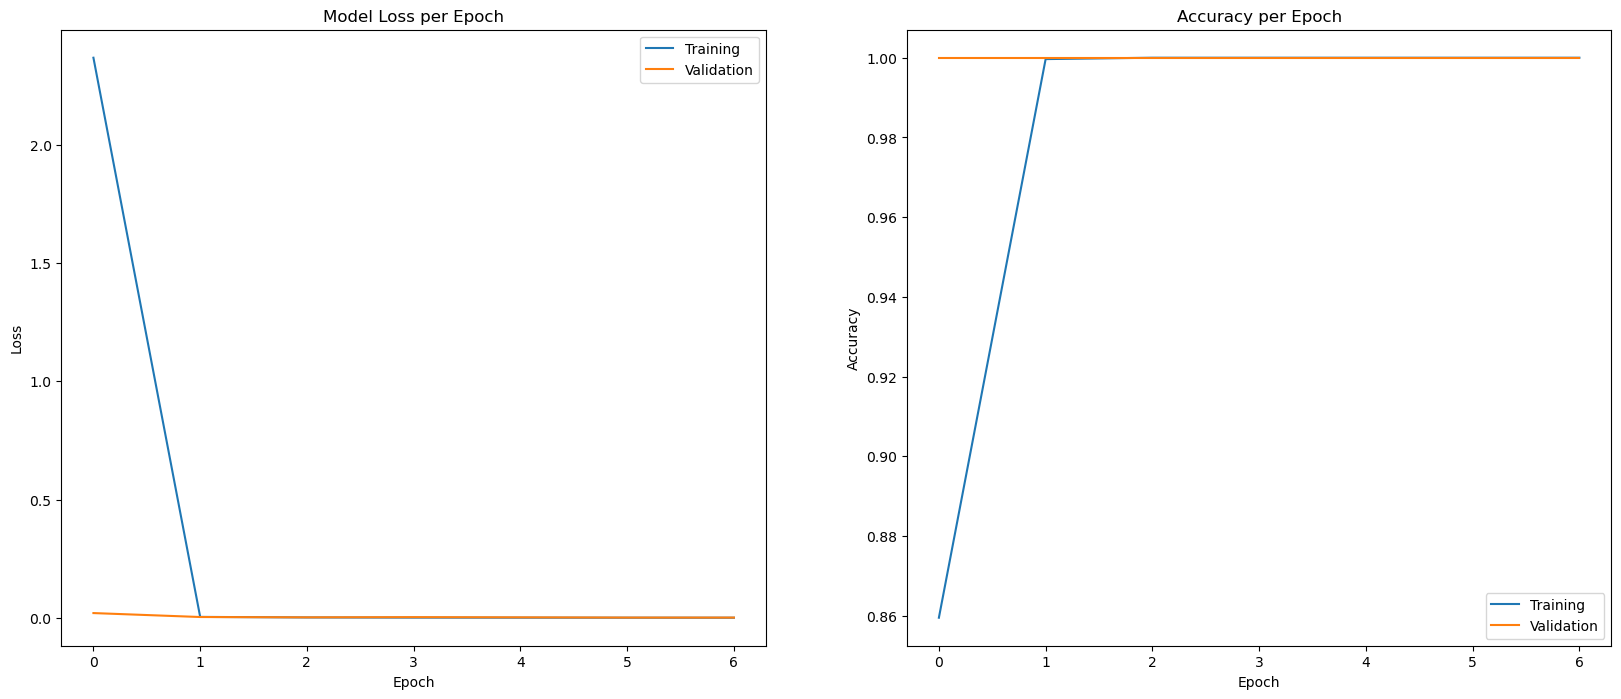

In [12]:
# Visualise model training (evolution of loss function and accuracy per epoch)

plot_training(model_history)


In [34]:
# Save model architecture and weights

model.save('cnn_obj_classifier.keras')
model.save_weights('cnn_obj_classifier.weights.h5')


In [32]:
# Assess model performance with holdout data (MVTec 'test' 'good' only)

test_ds = image_dataset_from_directory(
    test_good_data,
    seed=24,
    batch_size=16,
)  

y_true, y_pred = get_predictions_and_labels(model, test_ds)  # Get true labels and predictions from the test dataset

# Display the classification report
print(classification_report(y_true, y_pred))  # Print the classification report (precision, recall, F1-score)


Found 467 files belonging to 15 classes.
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        58
           2       1.00      1.00      1.00        23
           3       1.00      1.00      1.00        28
           4       1.00      1.00      1.00        21
           5       1.00      1.00      1.00        40
           6       1.00      1.00      1.00        32
           7       1.00      1.00      1.00        22
           8       1.00      1.00      1.00        26
           9       1.00      1.00      1.00        41
          10       1.00      1.00      1.00        33
          11       1.00      1.00      1.00        12
          12       1.00      1.00      1.00        60
          13       1.00      1.00      1.00        19
          14       1.00      1.00      1.00        32

    accuracy                           1.00       467
   macro avg       1.00      1.00      

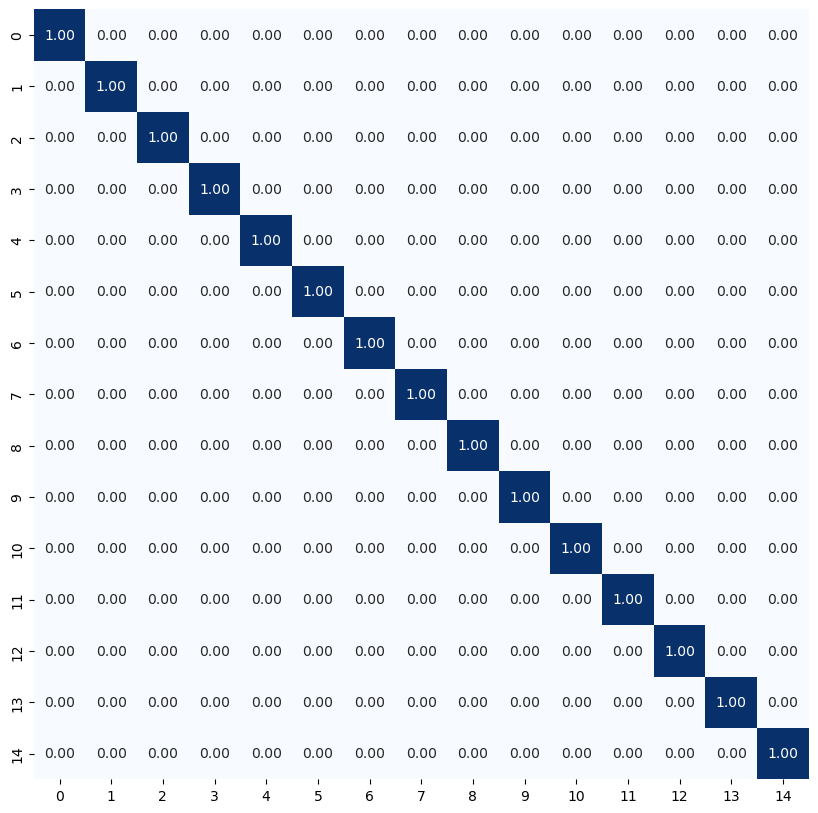

In [35]:
# Display the confusion matrix

plot_cm(y_true, y_pred)


In [13]:
# Assess model performance with holdout data (test good and all anomaly types)

test_ds = image_dataset_from_directory(
    test_data,
    seed=24,
    batch_size=32,
)  

y_true, y_pred = get_predictions_and_labels(model, test_ds)  # Get true labels and predictions from the test dataset

# Display the classification report
print(classification_report(y_true, y_pred))  # Print the classification report (precision, recall, F1-score)


Found 1725 files belonging to 15 classes.


2026-02-04 18:01:02.400441: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 25165824 bytes after encountering the first element of size 25165824 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        83
           1       1.00      1.00      1.00       150
           2       1.00      1.00      1.00       132
           3       1.00      1.00      1.00       117
           4       1.00      1.00      1.00        78
           5       1.00      1.00      1.00       110
           6       0.99      1.00      1.00       124
           7       1.00      1.00      1.00       115
           8       1.00      1.00      1.00       167
           9       1.00      1.00      1.00       160
          10       1.00      1.00      1.00       117
          11       1.00      1.00      1.00        42
          12       1.00      0.99      0.99       100
          13       1.00      1.00      1.00        79
          14       1.00      1.00      1.00       151

    accuracy                           1.00      1725
   macro avg       1.00      1.00      1.00      1725
weighted avg       1.00   

2026-02-04 18:01:13.186228: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


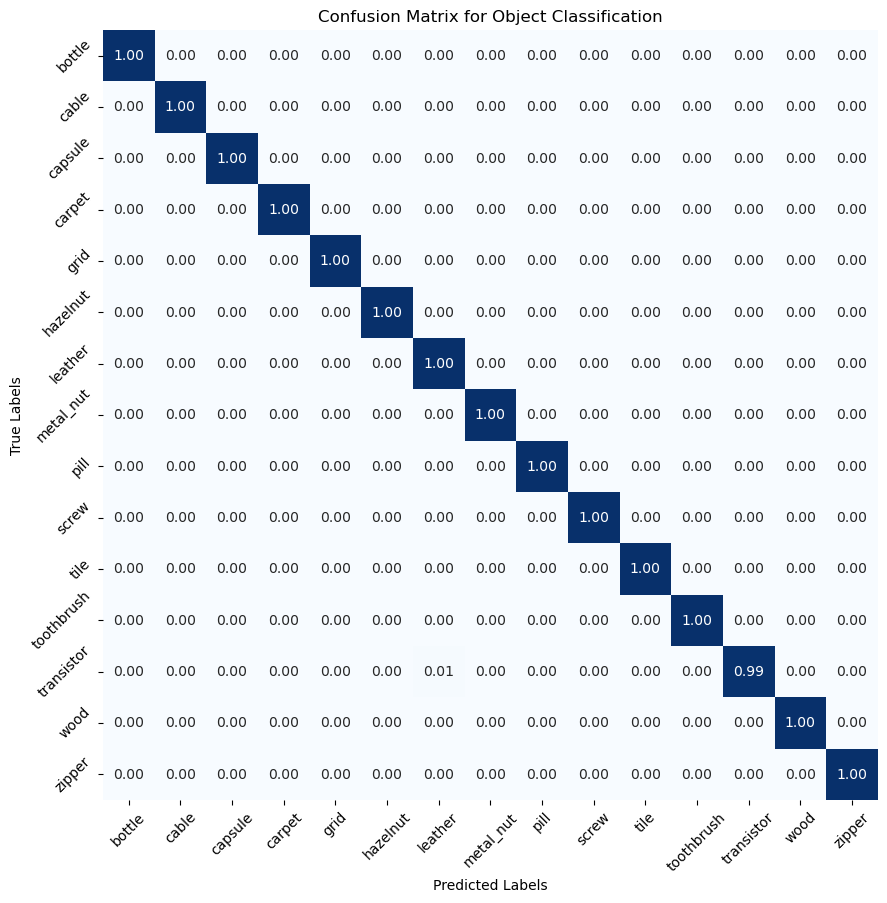

In [21]:
# Display the confusion matrix

plot_cm(y_true, y_pred, title='Confusion Matrix for Object Classification', labels=categories)


In [16]:
model.save('/home/suzy/datascientest/anomalie_proj/git_repo_ds/nov25_cds_anomalie/notebooks/cnn_obj_class_256x256.keras')
model.save_weights('/home/suzy/datascientest/anomalie_proj/git_repo_ds/nov25_cds_anomalie/notebooks/cnn_obj_class_256x256.keras.weights.h5')


### Interpretability

In [9]:
# Load saved model 

import keras

model = keras.saving.load_model('/home/suzy/datascientest/anomalie_proj/git_repo_ds/nov25_cds_anomalie/notebooks/cnn_obj_class_256x256.keras')

In [10]:
# Take images from validation set


class_names = sorted(os.listdir(f'{obj_data}'))

X = np.array([img.numpy() for img, _ in val_ds.take(2)][0]).astype(np.uint8)
y = np.array([label.numpy() for _, label in val_ds.take(2)][0])

# Select specific images
images = X[:4]
labels = y[:4]


2026-02-07 17:59:37.279075: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-07 17:59:38.365801: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


2026-02-07 18:00:00.576726: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 66064384 exceeds 10% of free system memory.
2026-02-07 18:00:00.662510: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 66064384 exceeds 10% of free system memory.
2026-02-07 18:00:00.723820: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 66064384 exceeds 10% of free system memory.
2026-02-07 18:00:01.577269: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 82580480 exceeds 10% of free system memory.
2026-02-07 18:00:01.662680: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 82580480 exceeds 10% of free system memory.


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  25%|█████████████████████████████▌                                                                                        | 1/4 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  75%|██████████████████████████████████████████████████████████████████████████████████▌                           | 3/4 [02:03<00:28, 28.64s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [02:57<00:00, 39.12s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 5it [03:53, 58.50s/it]                                                                                                                           


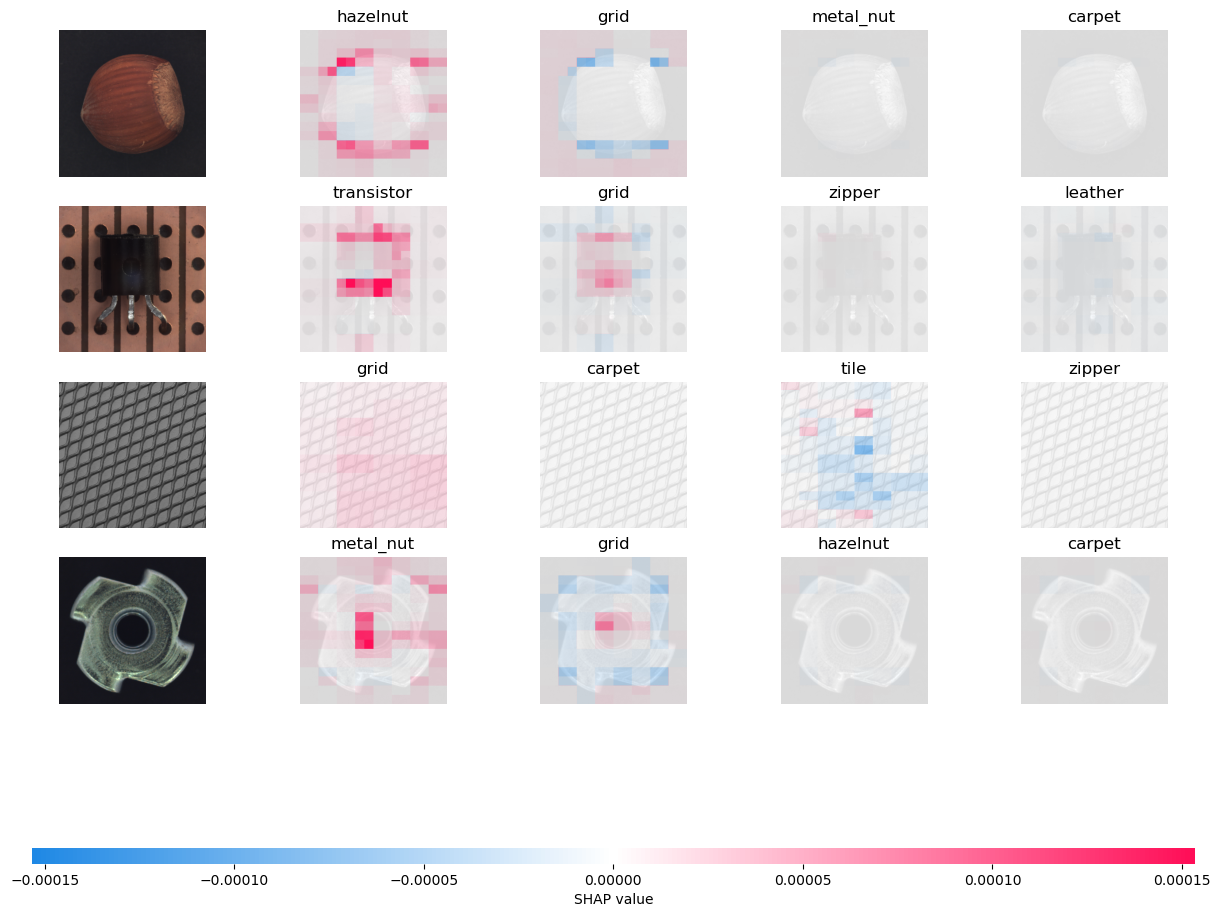

In [11]:
# SHAP

import shap

# Initialize the SHAP masker
masker = shap.maskers.Image("inpaint_telea", images[0].shape)

# Create the SHAP explainer
explainer = shap.Explainer(model, masker, output_names=class_names)

# Calculate SHAP values for the images we want to explain
shap_values = explainer(images, max_evals=500, outputs=shap.Explanation.argsort.flip[:4])

shap.image_plot(shap_values)


In [12]:
# Grad-CAM

import tensorflow as tf

def grad_cam(image, model, layer_name):
    # Retrieve the convolutional layer
    layer = model.get_layer(layer_name)
    
    # Create a model that generates the outputs of the convolutional layer and the predictions
    grad_model = Model(inputs=model.input, outputs=[layer.output, model.output])

    # Add a batch dimension
    image = tf.expand_dims(image, axis=0)

    # Compute the gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image)
        predicted_class = tf.argmax(predictions[0])  # Predicted class
        loss = predictions[:, predicted_class]  # Loss for the predicted class

    # Gradients of the scores with respect to the outputs of the convolutional layer
    grads = tape.gradient(loss, conv_outputs)

    # Weighted average of the gradients for each channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the activations by the calculated gradients
    conv_outputs = conv_outputs[0]  # Remove the batch dimension
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    # Normalize the heatmap
    heatmap = tf.maximum(heatmap, 0)  # Focus only on positive values
    heatmap /= tf.math.reduce_max(heatmap)  # Normalize between 0 and 1
    heatmap = heatmap.numpy()  # Convert to numpy array for visualization

    # Resize the heatmap to match the original image size
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], (image.shape[1], image.shape[2])).numpy()
    heatmap_resized = np.squeeze(heatmap_resized, axis=-1)  # Remove the singleton dimension at the end of the heatmap_resized array

    # Color the heatmap with a palette (e.g., "jet")
    heatmap_colored = plt.cm.jet(heatmap_resized)[..., :3]  # Get the R, G, B channels 

    superimposed_image = heatmap_colored * 0.7 + image[0].numpy() / 255.0

    return np.clip(superimposed_image, 0, 1), predicted_class


def show_grad_cam_cnn(images, model):
    number_of_images = images.shape[0]
    conv_layers = [layer.name for layer in model.layers if isinstance(layer, Conv2D)]

    plt.figure(figsize=(16,16))

    for j, layer in enumerate(conv_layers):

        for i in range(number_of_images):

            subplot_index = i + 1 + j * number_of_images
            plt.subplot(len(conv_layers), number_of_images, subplot_index)

            # Get the image with the overlaid heatmap
            grad_cam_image, predicted_class = grad_cam(images[i], model, layer)
            
            # Display the image with Grad-CAM
            plt.title(f'Grad-CAM {layer}')
            plt.imshow(grad_cam_image)
            plt.axis("off")

    plt.show()



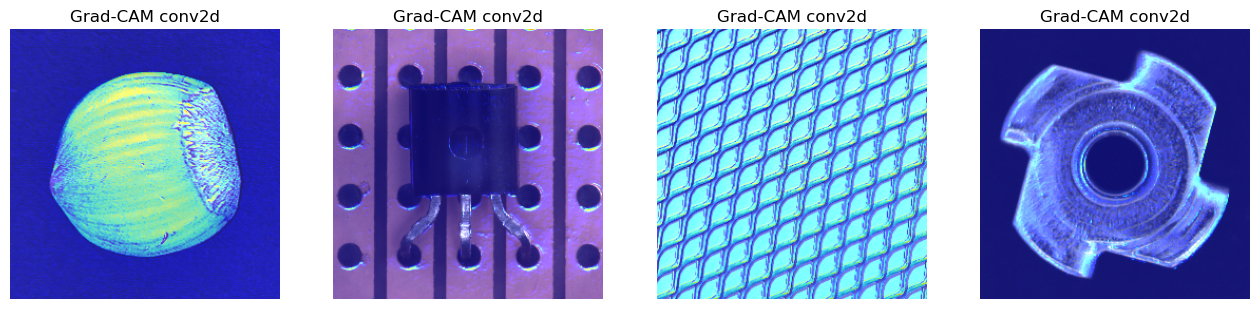

In [13]:
show_grad_cam_cnn(images, model)


## CNN for multi-class anomaly classification

In [16]:
data_dir = f"{data_location}/transistor/test"  

train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,       # Fraction of the data used for validation
    subset="training",          # Load the training data
    seed=42,                    # Seed for data splitting
    batch_size=16               # Batch size
)

val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,       # Fraction of the data used for validation
    subset="validation",        # Load the validation data
    seed=42,
    batch_size=16
)


Found 100 files belonging to 5 classes.
Using 80 files for training.
Found 100 files belonging to 5 classes.
Using 20 files for validation.


In [17]:
anoms = [p.name for p in Path(data_dir).iterdir() if p.is_dir()]

print('Anomaly type to label mapping:')
for label, obj in enumerate(anoms):
    print(f'{label}: {obj}')
    

Anomaly type to label mapping:
0: bent_lead
1: cut_lead
2: damaged_case
3: good
4: misplaced


In [49]:
model_history = model.fit(train_ds,
                          validation_data=val_ds,
                          epochs=30,) 


Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 700ms/step - accuracy: 0.4875 - loss: 1.6775 - val_accuracy: 0.6000 - val_loss: 1.5962
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 412ms/step - accuracy: 0.6500 - loss: 1.0791 - val_accuracy: 0.6000 - val_loss: 1.2445
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 498ms/step - accuracy: 0.6750 - loss: 0.8893 - val_accuracy: 0.6000 - val_loss: 1.1184
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 456ms/step - accuracy: 0.7750 - loss: 0.7509 - val_accuracy: 0.6000 - val_loss: 1.0515
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 445ms/step - accuracy: 0.7875 - loss: 0.6135 - val_accuracy: 0.5500 - val_loss: 1.3043
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 335ms/step - accuracy: 0.8000 - loss: 0.5619 - val_accuracy: 0.6000 - val_loss: 0.8768
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 328ms/step - accuracy: 0.8125 - loss: 0.4854 - val_accuracy: 0.6000 - val_loss: 0.9319
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 330ms/step - accuracy: 0.8250 - loss: 0.4460 - val_accuracy: 0.6000 - val_loss:

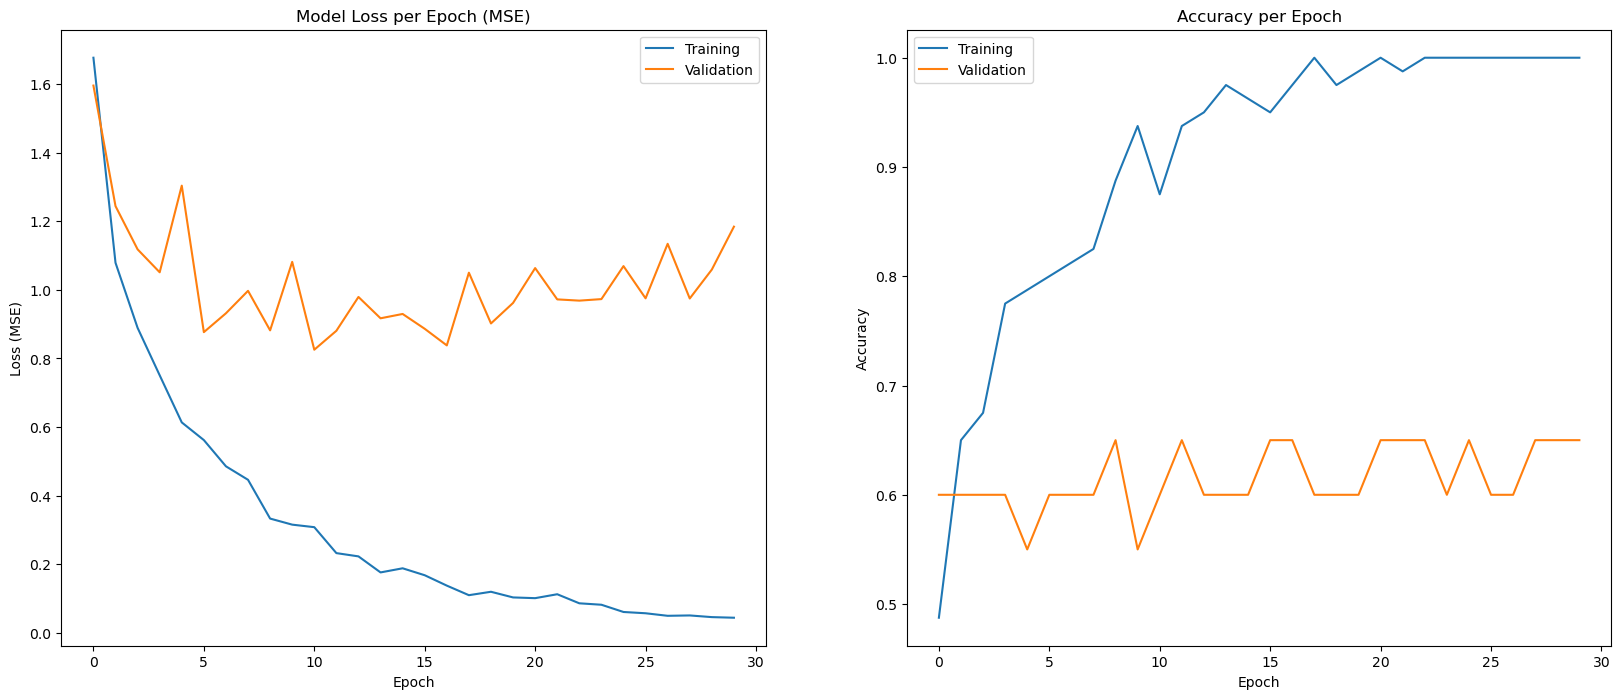

In [50]:
plot_training(model_history)


## Data augmentation for anomaly minority classes (binary classification)

In [18]:
# Augment all anomaly images for transistor

# Adapted from: https://pyimagesearch.com/2019/07/08/keras-imagedatagenerator-and-data-augmentation/


'''
Data in root_dir was produced by taking data from {test_all_data}/transistor and deleting all images from good category via 'rm *good*'
'''

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img

imgs_to_gen = 7
root_dir = Path('/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_binary/augmented/transistor/all_anomalies')
output_dir = os.path.join(root_dir, 'augmented_imgs')

img_files = [f for f in root_dir.rglob('*.png') if f.is_file()]

for img_file in img_files:
    img_prefix = str(img_file).split('/')[-1].strip('.png')
    
    #print(f"[INFO] loading image {img_prefix}.png...")
    image = load_img(img_file)
    image = img_to_array(image)
    image = np.expand_dims(image, axis=0)
    
    # Construct the image generator for data augmentation then
    aug = ImageDataGenerator(
       rotation_range=15,       # rotate images by ±15 degrees
       width_shift_range=0.1,   # 10% horizontal shift
       height_shift_range=0.1,  # 10% vertical shift
       zoom_range=0.1,          # zoom in/out by 10%
       shear_range=0.1,         # apply shear transformation
       horizontal_flip=False,   # not needed
       fill_mode='nearest'      # fill missing pixels after transformations
    )

    # Initialize the total number of images generated thus far
    total = 0
    
    # Construct the actual Python generator
    #print(f"[INFO] generating {imgs_to_gen} augmented images...")
    imageGen = aug.flow(image, batch_size=1, save_to_dir=output_dir,
    	save_prefix=img_prefix, save_format="png")
    # Loop over examples from our image data augmentation generator
    for image in imageGen:
    	# increment our counter
    	total += 1
    	# If we have reached the specified number of examples, break from the loop
    	if total == imgs_to_gen:
    		break


[INFO] loading image bent_lead_000.png...
[INFO] generating 7 augmented images...
[INFO] loading image bent_lead_001.png...
[INFO] generating 7 augmented images...
[INFO] loading image bent_lead_002.png...
[INFO] generating 7 augmented images...
[INFO] loading image bent_lead_003.png...
[INFO] generating 7 augmented images...
[INFO] loading image bent_lead_004.png...
[INFO] generating 7 augmented images...
[INFO] loading image bent_lead_005.png...
[INFO] generating 7 augmented images...
[INFO] loading image bent_lead_006.png...
[INFO] generating 7 augmented images...
[INFO] loading image bent_lead_007.png...
[INFO] generating 7 augmented images...
[INFO] loading image bent_lead_008.png...
[INFO] generating 7 augmented images...
[INFO] loading image bent_lead_009.png...
[INFO] generating 7 augmented images...
[INFO] loading image cut_lead_000.png...
[INFO] generating 7 augmented images...
[INFO] loading image cut_lead_001.png...
[INFO] generating 7 augmented images...
[INFO] loading ima

In [28]:
print('After augmentation, total transistor dataset is 320 (280 augmented + 40 original) images with anomalies and 273 without.\n')
print('A holdout test dataset will be pre-split (this will contain a mixture of good as well as original and augmented anomaly images taking care not to only include augmented versions of originals used for training).')


After augmentation, total transistor dataset is 320 (280 augmented + 40 original) images with anomalies and 273 without.

A holdout test dataset will be pre-split (this will contain a mixture of good as well as original and augmented anomaly images taking care not to only include augmented versions of originals used for training).


In [6]:
# Set up training with augmented data

# 'good' test and train data combined for transistor
# 7 augmented images made for each transistor anomaly image
# 50 random images are taken from 'good' and 'anomaly' classes to make the holdout test set

augmented_dir = '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_binary/augmented/transistor/pre_split/train'
holdout_dir = '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_binary/augmented/transistor/pre_split/holdout'

train_ds = image_dataset_from_directory(
    augmented_dir,
    validation_split=0.2,       # Fraction of the data used for validation
    subset="training",          # Load the training data
    seed=42,                    # Seed for data splitting
    batch_size=16               # Batch size
)

val_ds = image_dataset_from_directory(
    augmented_dir,
    validation_split=0.2,       # Fraction of the data used for validation
    subset="validation",        # Load the validation data
    seed=42,
    batch_size=16
)

test_ds = image_dataset_from_directory(
    holdout_dir,
    seed=24,
    batch_size=16,
)  


Found 493 files belonging to 2 classes.
Using 395 files for training.
Found 493 files belonging to 2 classes.
Using 98 files for validation.
Found 100 files belonging to 2 classes.


In [8]:
cats = [p.name for p in Path(augmented_dir).iterdir() if p.is_dir()]

print('Category to label mapping:')
for label, obj in enumerate(cats):
    print(f'{label}: {obj}')
    

Category to label mapping:
0: good
1: all_anomalies


In [13]:
model_history = model_bin.fit(train_ds,
                          validation_data=val_ds,
                          epochs=30,
                          callbacks=[early_stopping]
                         )


Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 267ms/step - accuracy: 0.8329 - loss: 0.3972 - val_accuracy: 0.9388 - val_loss: 0.2234
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 251ms/step - accuracy: 0.9266 - loss: 0.1874 - val_accuracy: 0.9388 - val_loss: 0.1707
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 244ms/step - accuracy: 0.9418 - loss: 0.1401 - val_accuracy: 0.9490 - val_loss: 0.1511
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 231ms/step - accuracy: 0.9595 - loss: 0.1215 - val_accuracy: 0.9490 - val_loss: 0.1336
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 222ms/step - accuracy: 0.9519 - loss: 0.1162 - val_accuracy: 0.9592 - val_loss: 0.1325


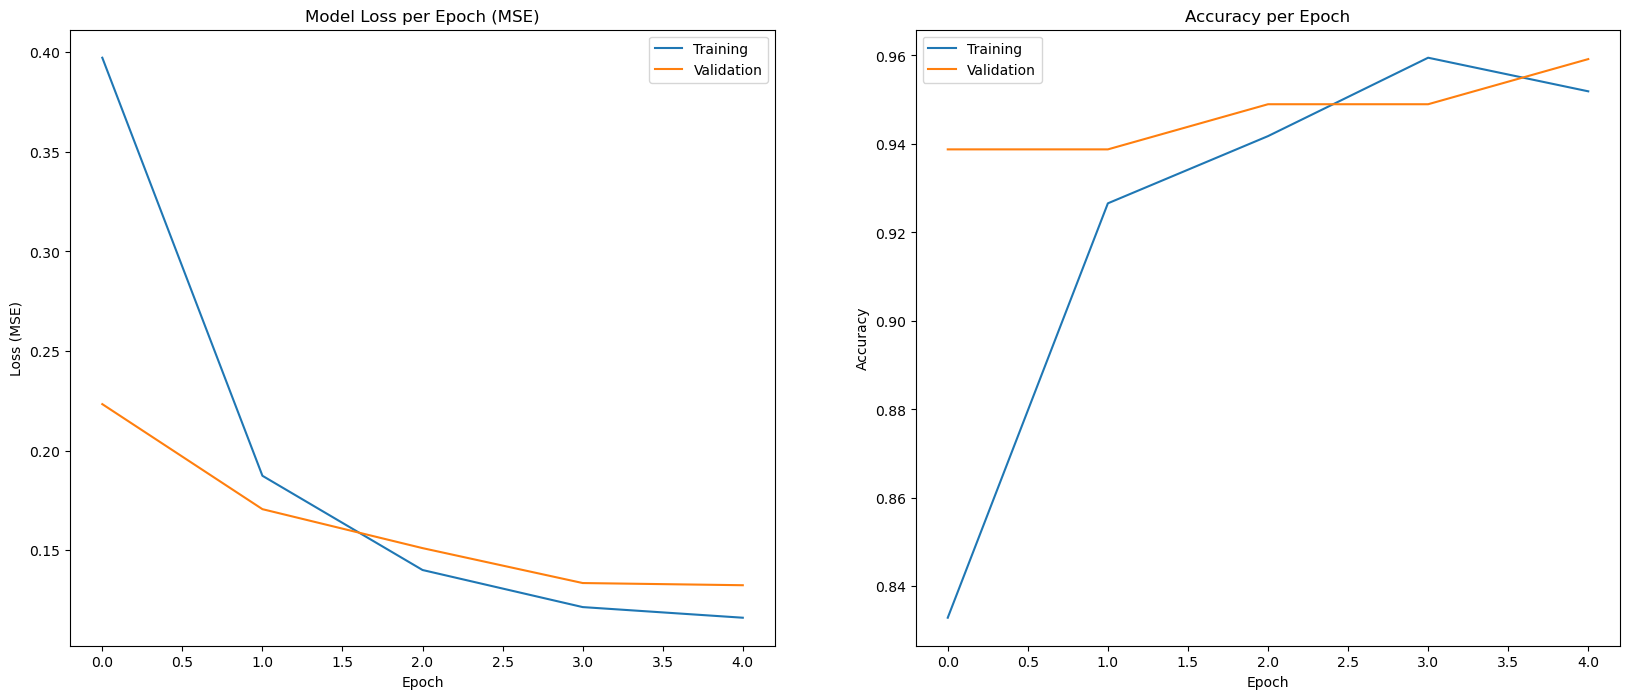

In [14]:
plot_training(model_history)


In [15]:
y_true, y_pred = get_predictions_and_labels(model_bin, test_ds)  # Get true labels and predictions from the test dataset

# Display the classification report
print(classification_report(y_true, y_pred))  # Print the classification report (precision, recall, F1-score)


              precision    recall  f1-score   support

           0       0.98      0.94      0.96        50
           1       0.94      0.98      0.96        50

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



2026-01-27 14:44:18.700570: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


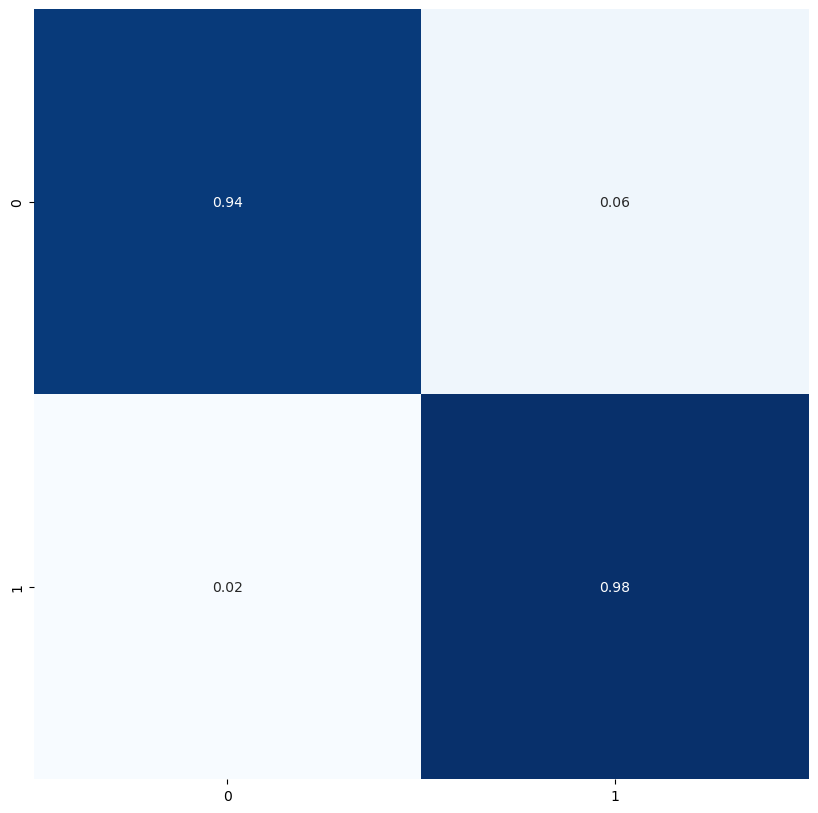

In [16]:
# Display the confusion matrix

plot_cm(y_true, y_pred)


## Analysis of results:
Performance of above model is very good, but all defect images were augmented and then split which likely resulting in a data leak (the holdout dataset was not truly 'unseen', the model was retrained assuring no augmented versions of images used for training were in the holdout set and we see in the model below that the model then performed very poorly unable to classify the anomaly class.

In [18]:
# Set up training with augmented data **DATA AUGMENTED AFTER SPLITTING HOLDOUT DATA TO AVOID DATA LEAK**

augmented_dir = '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_binary/split_before_augmentation/transistor/train'
holdout_dir = '/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_binary/split_before_augmentation/transistor/holdout'

train_ds = image_dataset_from_directory(
    augmented_dir,
    validation_split=0.2,       # Fraction of the data used for validation
    subset="training",          # Load the training data
    seed=42,                    # Seed for data splitting
    batch_size=16               # Batch size
)

val_ds = image_dataset_from_directory(
    augmented_dir,
    validation_split=0.2,       # Fraction of the data used for validation
    subset="validation",        # Load the validation data
    seed=42,
    batch_size=16
)

test_ds = image_dataset_from_directory(
    holdout_dir,
    seed=24,
    batch_size=16,
)  


Found 446 files belonging to 2 classes.
Using 357 files for training.
Found 446 files belonging to 2 classes.
Using 89 files for validation.
Found 106 files belonging to 2 classes.


In [19]:
model_history = model_bin.fit(train_ds,
                          validation_data=val_ds,
                          epochs=30,
                          callbacks=[early_stopping]
                         )


Epoch 1/30


2026-01-28 14:03:27.878970: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 12582912 exceeds 10% of free system memory.
2026-01-28 14:03:28.014981: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 12582912 exceeds 10% of free system memory.
2026-01-28 14:03:28.130076: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 19668992 exceeds 10% of free system memory.
2026-01-28 14:03:28.235668: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 12582912 exceeds 10% of free system memory.
2026-01-28 14:03:28.288417: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 9834496 exceeds 10% of free system memory.


23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 451ms/step - accuracy: 0.8487 - loss: 0.3956 - val_accuracy: 0.9213 - val_loss: 0.2077
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 342ms/step - accuracy: 0.9244 - loss: 0.1971 - val_accuracy: 0.9326 - val_loss: 0.2108
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 369ms/step - accuracy: 0.9384 - loss: 0.1660 - val_accuracy: 0.9213 - val_loss: 0.2111
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 242ms/step - accuracy: 0.9356 - loss: 0.1430 - val_accuracy: 0.9326 - val_loss: 0.1783
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 247ms/step - accuracy: 0.9580 - loss: 0.1162 - val_accuracy: 0.9101 - val_loss: 0.1928
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 228ms/step - accuracy: 0.9580 - loss: 0.1098 - val_accuracy: 0.9438 - val_loss: 0.1575
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 220ms/step - accuracy: 0.9692 - loss: 0.0860 - val_accuracy: 0.9438 - val_loss: 0.1593
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 228ms/step - accuracy: 0.9692 - loss: 0.0878 - val_accuracy: 0.9438 - val

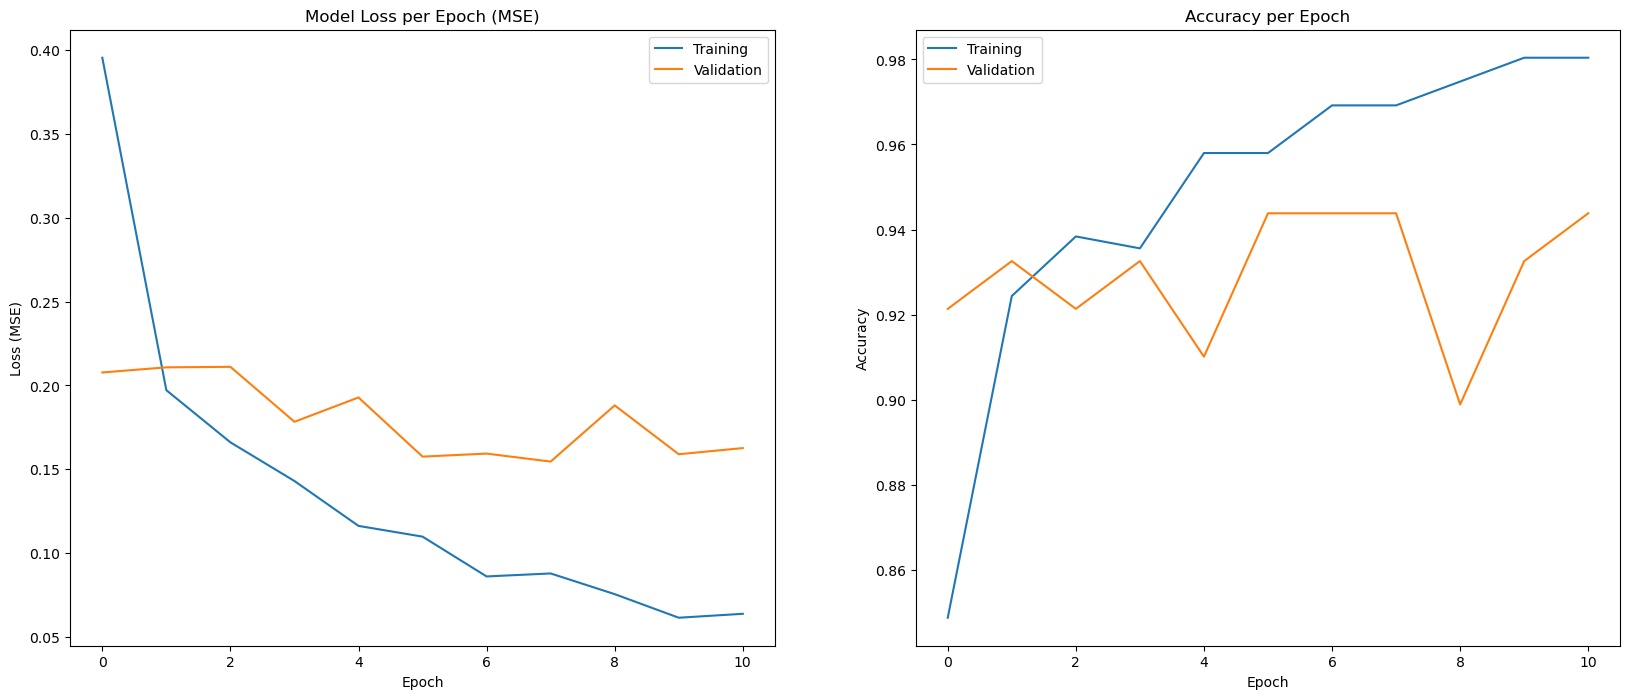

In [20]:
plot_training(model_history)


In [27]:
y_true, y_pred = get_predictions_and_labels(model_bin, test_ds)  # Get true labels and predictions from the test dataset

# Display the classification report
print(classification_report(y_true, y_pred))  # Print the classification report (precision, recall, F1-score)


              precision    recall  f1-score   support

           0       0.53      1.00      0.69        56
           1       0.00      0.00      0.00        50

    accuracy                           0.53       106
   macro avg       0.26      0.50      0.35       106
weighted avg       0.28      0.53      0.37       106



2026-01-28 14:24:16.296299: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being se

In [28]:
cm_bin(y_true, y_pred)


Predicted Class,0
True Class,
0,56
1,50


## CNN for binary anomaly classification (without data augmentation)
We see here very poor recall for the minority anomaly class

In [29]:
data_dir = "/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_binary/transistor"  

train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,       # Fraction of the data used for validation
    subset="training",          # Load the training data
    seed=42,                    # Seed for data splitting
    batch_size=16               # Batch size
)

val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,       # Fraction of the data used for validation
    subset="validation",        # Load the validation data
    seed=42,
    batch_size=16
)


Found 100 files belonging to 2 classes.
Using 80 files for training.
Found 100 files belonging to 2 classes.
Using 20 files for validation.


In [30]:
cats = [p.name for p in Path("/home/suzy/datascientest/anomalie_proj/datasets/CNN/MVTec/anomalies_binary/transistor").iterdir() if p.is_dir()]

print('Category to label mapping:')
for label, obj in enumerate(cats):
    print(f'{label}: {obj}')
    

Category to label mapping:
0: good
1: all_anomalies


In [31]:
model_history = model_bin.fit(train_ds,
                          validation_data=val_ds,
                          epochs=30,
                         callbacks=[early_stopping]) 


Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 324ms/step - accuracy: 0.8500 - loss: 0.3634 - val_accuracy: 0.6500 - val_loss: 0.5965
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 306ms/step - accuracy: 0.8375 - loss: 0.4418 - val_accuracy: 0.9000 - val_loss: 0.3132
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 275ms/step - accuracy: 0.8625 - loss: 0.3044 - val_accuracy: 0.7500 - val_loss: 0.4413
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step - accuracy: 0.8750 - loss: 0.3006 - val_accuracy: 0.9500 - val_loss: 0.3156
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 283ms/step - accuracy: 0.8875 - loss: 0.2783 - val_accuracy: 0.8000 - val_loss: 0.3369


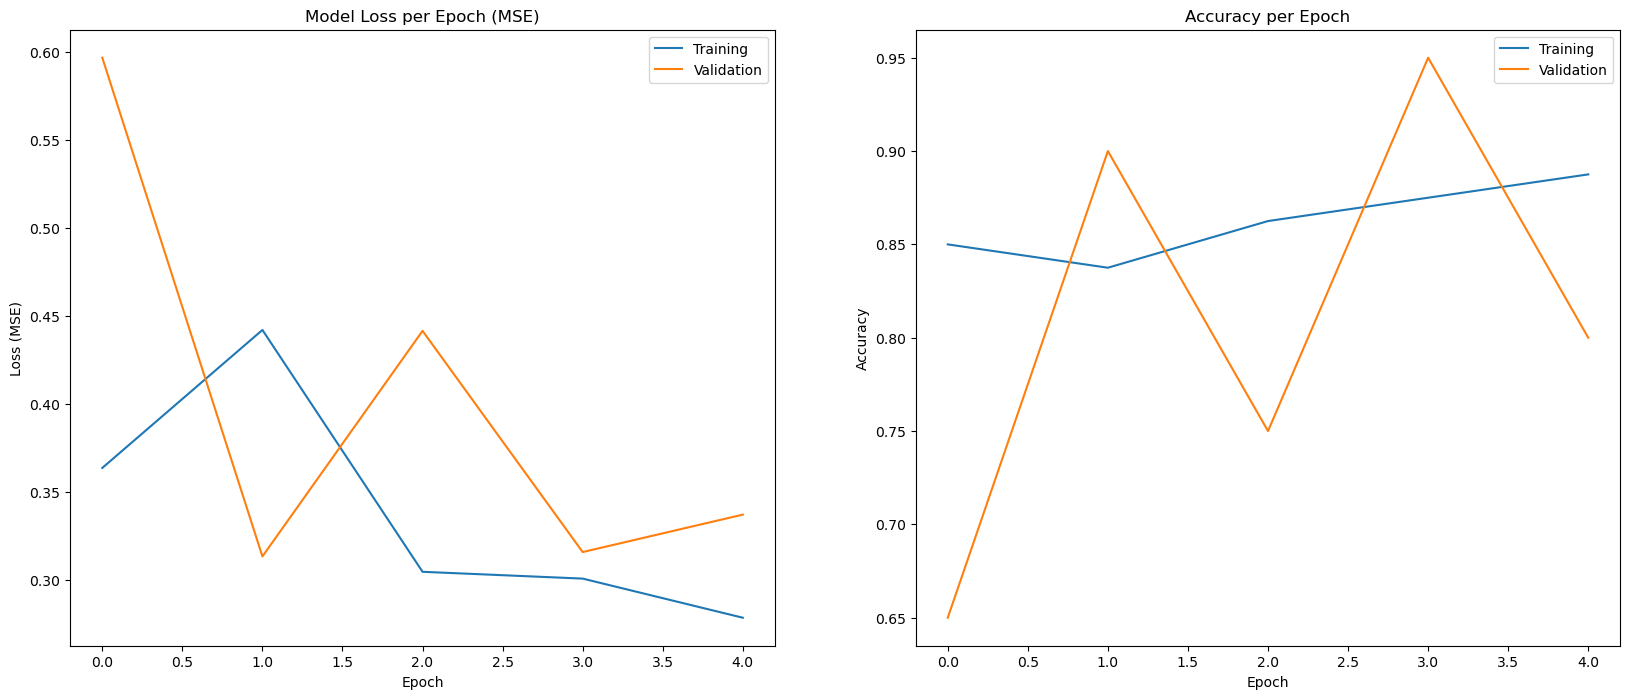

In [32]:
plot_training(model_history)


In [33]:
y_true, y_pred = get_predictions_and_labels(model_bin, test_ds)  # Get true labels and predictions from the test dataset

# Display the classification report
print(classification_report(y_true, y_pred))  # Print the classification report (precision, recall, F1-score)


              precision    recall  f1-score   support

           0       0.53      1.00      0.69        56
           1       0.00      0.00      0.00        50

    accuracy                           0.53       106
   macro avg       0.26      0.50      0.35       106
weighted avg       0.28      0.53      0.37       106



/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/suzy/.conda/envs/test_env/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

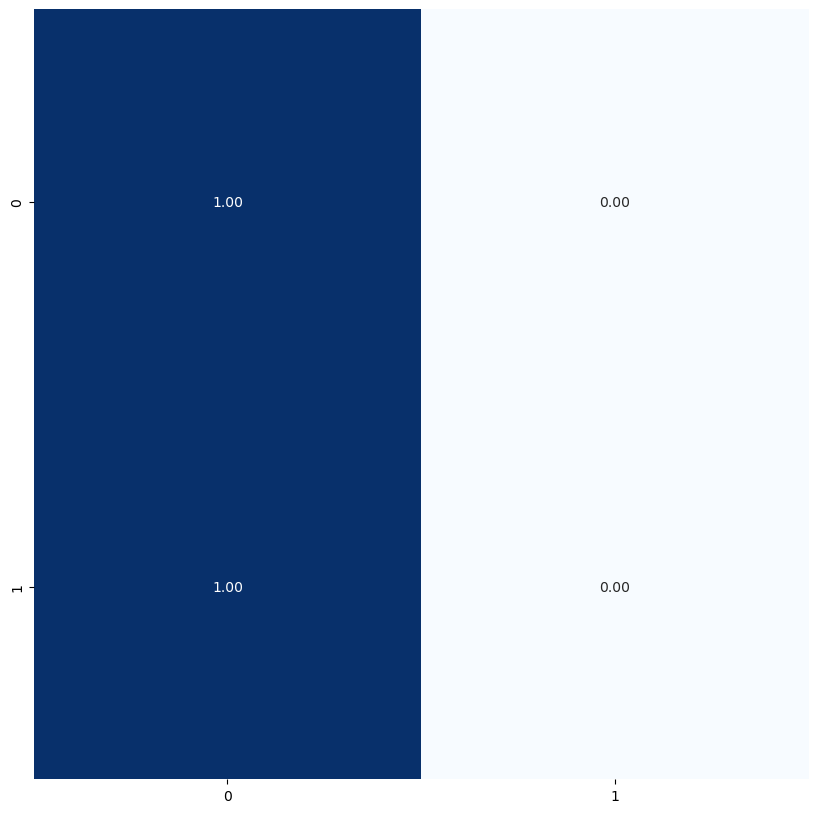

In [34]:
# Display the confusion matrix

plot_cm(y_true, y_pred)


# IMPORTANT
Further investigations with augmented data for anomaly detection are conducted in notebook '2.3-suzy-cnn-transistor-anomaly-detection.ipynb' using notebook '2.2-suzy-data-augmentation.ipynb' to perform data augmentation for pre-split train, validation and test sets.